# FASE 1 — Exploração de Dados

Dataset: PCOS_data_without_infertility.xlsx

Objetivo: carregar, explorar e entender os dados antes do pré-processamento.

## O problema: Síndrome dos Ovários Policísticos (PCOS)

A Síndrome dos Ovários Policísticos (PCOS) é um distúrbio hormonal que afeta entre 6% e 12% das mulheres em idade reprodutiva, sendo uma das principais causas de infertilidade feminina. A síndrome é caracterizada por três critérios diagnósticos (Consenso de Rotterdam, 2003): hiperandrogenismo (excesso de hormônios masculinos), disfunção ovulatória e ovários com morfologia policística ao ultrassom — sendo necessários pelo menos dois dos três para o diagnóstico.

Além do impacto reprodutivo, a PCOS está associada a complicações metabólicas de longo prazo: resistência à insulina, diabetes tipo 2, doenças cardiovasculares e distúrbios psicológicos como ansiedade e depressão. O diagnóstico precoce é fundamental para o manejo adequado, mas é frequentemente tardio — estima-se que até 70% das mulheres com PCOS não são diagnosticadas.

**Por que usar Machine Learning?** O diagnóstico de PCOS envolve a análise simultânea de múltiplas variáveis clínicas, hormonais e de imagem. Um modelo de classificação pode servir como **ferramenta de apoio à triagem**, identificando pacientes com maior probabilidade de ter a síndrome a partir de exames de rotina e acelerando o encaminhamento para confirmação clínica. O objetivo não é substituir o médico, mas sim reduzir o tempo até o diagnóstico.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carregando o dataset

In [2]:
# Carrega o arquivo Excel e mostra quantas linhas e colunas tem o dataset
df = pd.read_excel('../data/PCOS_data_without_infertility.xlsx', sheet_name='Full_new')
print(f'{df.shape[0]} linhas, {df.shape[1]} colunas')

541 linhas, 45 colunas


In [3]:
# Mostra as 5 primeiras linhas para entender a estrutura da tabela
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [4]:
# Estatísticas descritivas: count, média, desvio padrão, min, quartis e max de cada coluna numérica
df.describe()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,271.000000,0.327172,31.430684,59.637153,156.484835,24.311285,13.802218,73.247689,19.243993,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,4.056399,1.840812,4.430285,1.688629,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,1.000000,0.000000,20.000000,31.000000,137.000000,12.417882,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,136.000000,0.000000,28.000000,52.000000,152.000000,21.641274,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,271.000000,0.000000,31.000000,59.000000,156.000000,24.238227,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,406.000000,1.000000,35.000000,65.000000,160.000000,26.634958,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


In [5]:
# Mostra tipo de cada coluna (int, float, object) e quantidade de valores não nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    int64  
 15  

## 2. Tratamento de Dados

### 2.1 Verificando valores nulos

In [6]:
# Lista apenas as colunas que possuem valores nulos e quantos são
print('Valores nulos por coluna:')
nulos = df.isnull().sum()
nulos[nulos > 0]

Valores nulos por coluna:


Marraige Status (Yrs)      1
Fast food (Y/N)            1
Unnamed: 44              539
dtype: int64

### 2.2 Removendo colunas sem utilidade e convertendo object para numérico

Antes de imputar os nulos, dois passos de preparação são necessários:
- Remover `Coluna "Sl. No", Patient File No., Unnamed: 44`: coluna artefato do Excel com 539/541 valores nulos
- Converter `II beta-HCG(mIU/mL)` e `AMH(ng/mL)` de `object` para numérico (podem conter texto misturado)

In [7]:
# Remove colunas sem utilidade
# Unnamed: 44 é artefato do Excel (539/541 nulos), Sl. No e Patient File No. são IDs
cols_to_drop = ['Sl. No', 'Patient File No.', 'Unnamed: 44']
cols_exist = [c for c in cols_to_drop if c in df.columns]
if cols_exist:
    df = df.drop(columns=cols_exist)
    print(f'Colunas removidas: {cols_exist}')

# Converte colunas do tipo object para numérico
# errors='coerce': valores que não podem ser convertidos viram NaN
for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f'Coluna "{col}" convertida para numérico.')

print(f'\n{df.shape[0]} linhas, {df.shape[1]} colunas')
print('\nNulos após preparação:')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo.')

Colunas removidas: ['Sl. No', 'Patient File No.', 'Unnamed: 44']
Coluna "II    beta-HCG(mIU/mL)" convertida para numérico.
Coluna "AMH(ng/mL)" convertida para numérico.

541 linhas, 42 colunas

Nulos após preparação:
Marraige Status (Yrs)     1
II    beta-HCG(mIU/mL)    1
AMH(ng/mL)                1
Fast food (Y/N)           1
dtype: int64


### 2.3 Imputação com SimpleImputer

Utiliza a mediana de cada coluna para substituir os valores nulos.

In [8]:
from sklearn.impute import SimpleImputer

colunas_nulas = df.columns[df.isnull().any()].tolist()

if colunas_nulas:
    print('Colunas que serão imputadas:', colunas_nulas)
    # strategy='median': substitui cada NaN pela mediana da coluna
    imputer = SimpleImputer(strategy='median')
    df[colunas_nulas] = imputer.fit_transform(df[colunas_nulas])
    print(f'\nNulos restantes após SimpleImputer: {df.isnull().sum().sum()}')
else:
    print('Nenhuma coluna com valores nulos para imputar.')

print(f'Shape final: {df.shape}')

Colunas que serão imputadas: ['Marraige Status (Yrs)', 'II    beta-HCG(mIU/mL)', 'AMH(ng/mL)', 'Fast food (Y/N)']

Nulos restantes após SimpleImputer: 0
Shape final: (541, 42)


### 2.4 Verificação final

In [9]:
nulos_final = df.isnull().sum()
if nulos_final.sum() == 0:
    print('Nenhum valor nulo restante no dataset.')
else:
    print('Nulos restantes:')
    print(nulos_final[nulos_final > 0])

Nenhum valor nulo restante no dataset.


## 3. Distribuição da variável target (PCOS: sim/não)

In [10]:
# Contagem e proporção da variável alvo: quantas pacientes têm PCOS (1) e quantas não têm (0)
print('Distribuição da target:')
print(df['PCOS (Y/N)'].value_counts())
print(f'\nProporção: {df["PCOS (Y/N)"].value_counts(normalize=True).round(3)}')

Distribuição da target:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

Proporção: PCOS (Y/N)
0    0.673
1    0.327
Name: proportion, dtype: float64


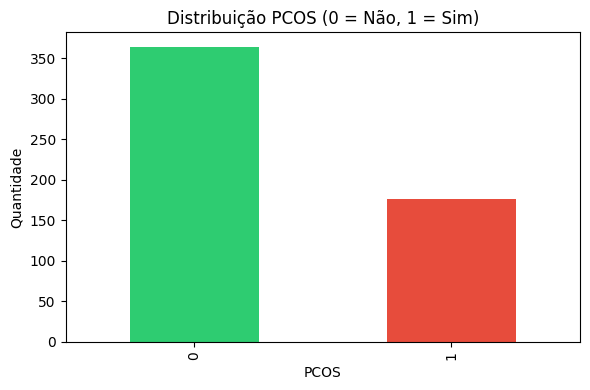

In [11]:
# Gráfico de barras para visualizar o balanceamento entre as classes
fig, ax = plt.subplots(figsize=(6, 4))
df['PCOS (Y/N)'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Distribuição PCOS (0 = Não, 1 = Sim)')
ax.set_xlabel('PCOS')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.show()

## 4. Estatísticas por classe

In [12]:
# Média de cada feature separada por classe (PCOS vs não-PCOS) para identificar diferenças
df.groupby('PCOS (Y/N)').mean(numeric_only=True).T

PCOS (Y/N),0,1
Age (yrs),32.065934,30.124294
Weight (Kg),58.008791,62.985876
Height(Cm),156.197934,157.074847
BMI,23.747397,25.470919
Blood Group,13.755495,13.898305
Pulse rate(bpm),72.964286,73.830508
RR (breaths/min),19.200549,19.333333
Hb(g/dl),11.107390,11.268305
Cycle(R/I),2.307692,3.079096
Cycle length(days),5.126374,4.559322


## 5. Histogramas das features por classe

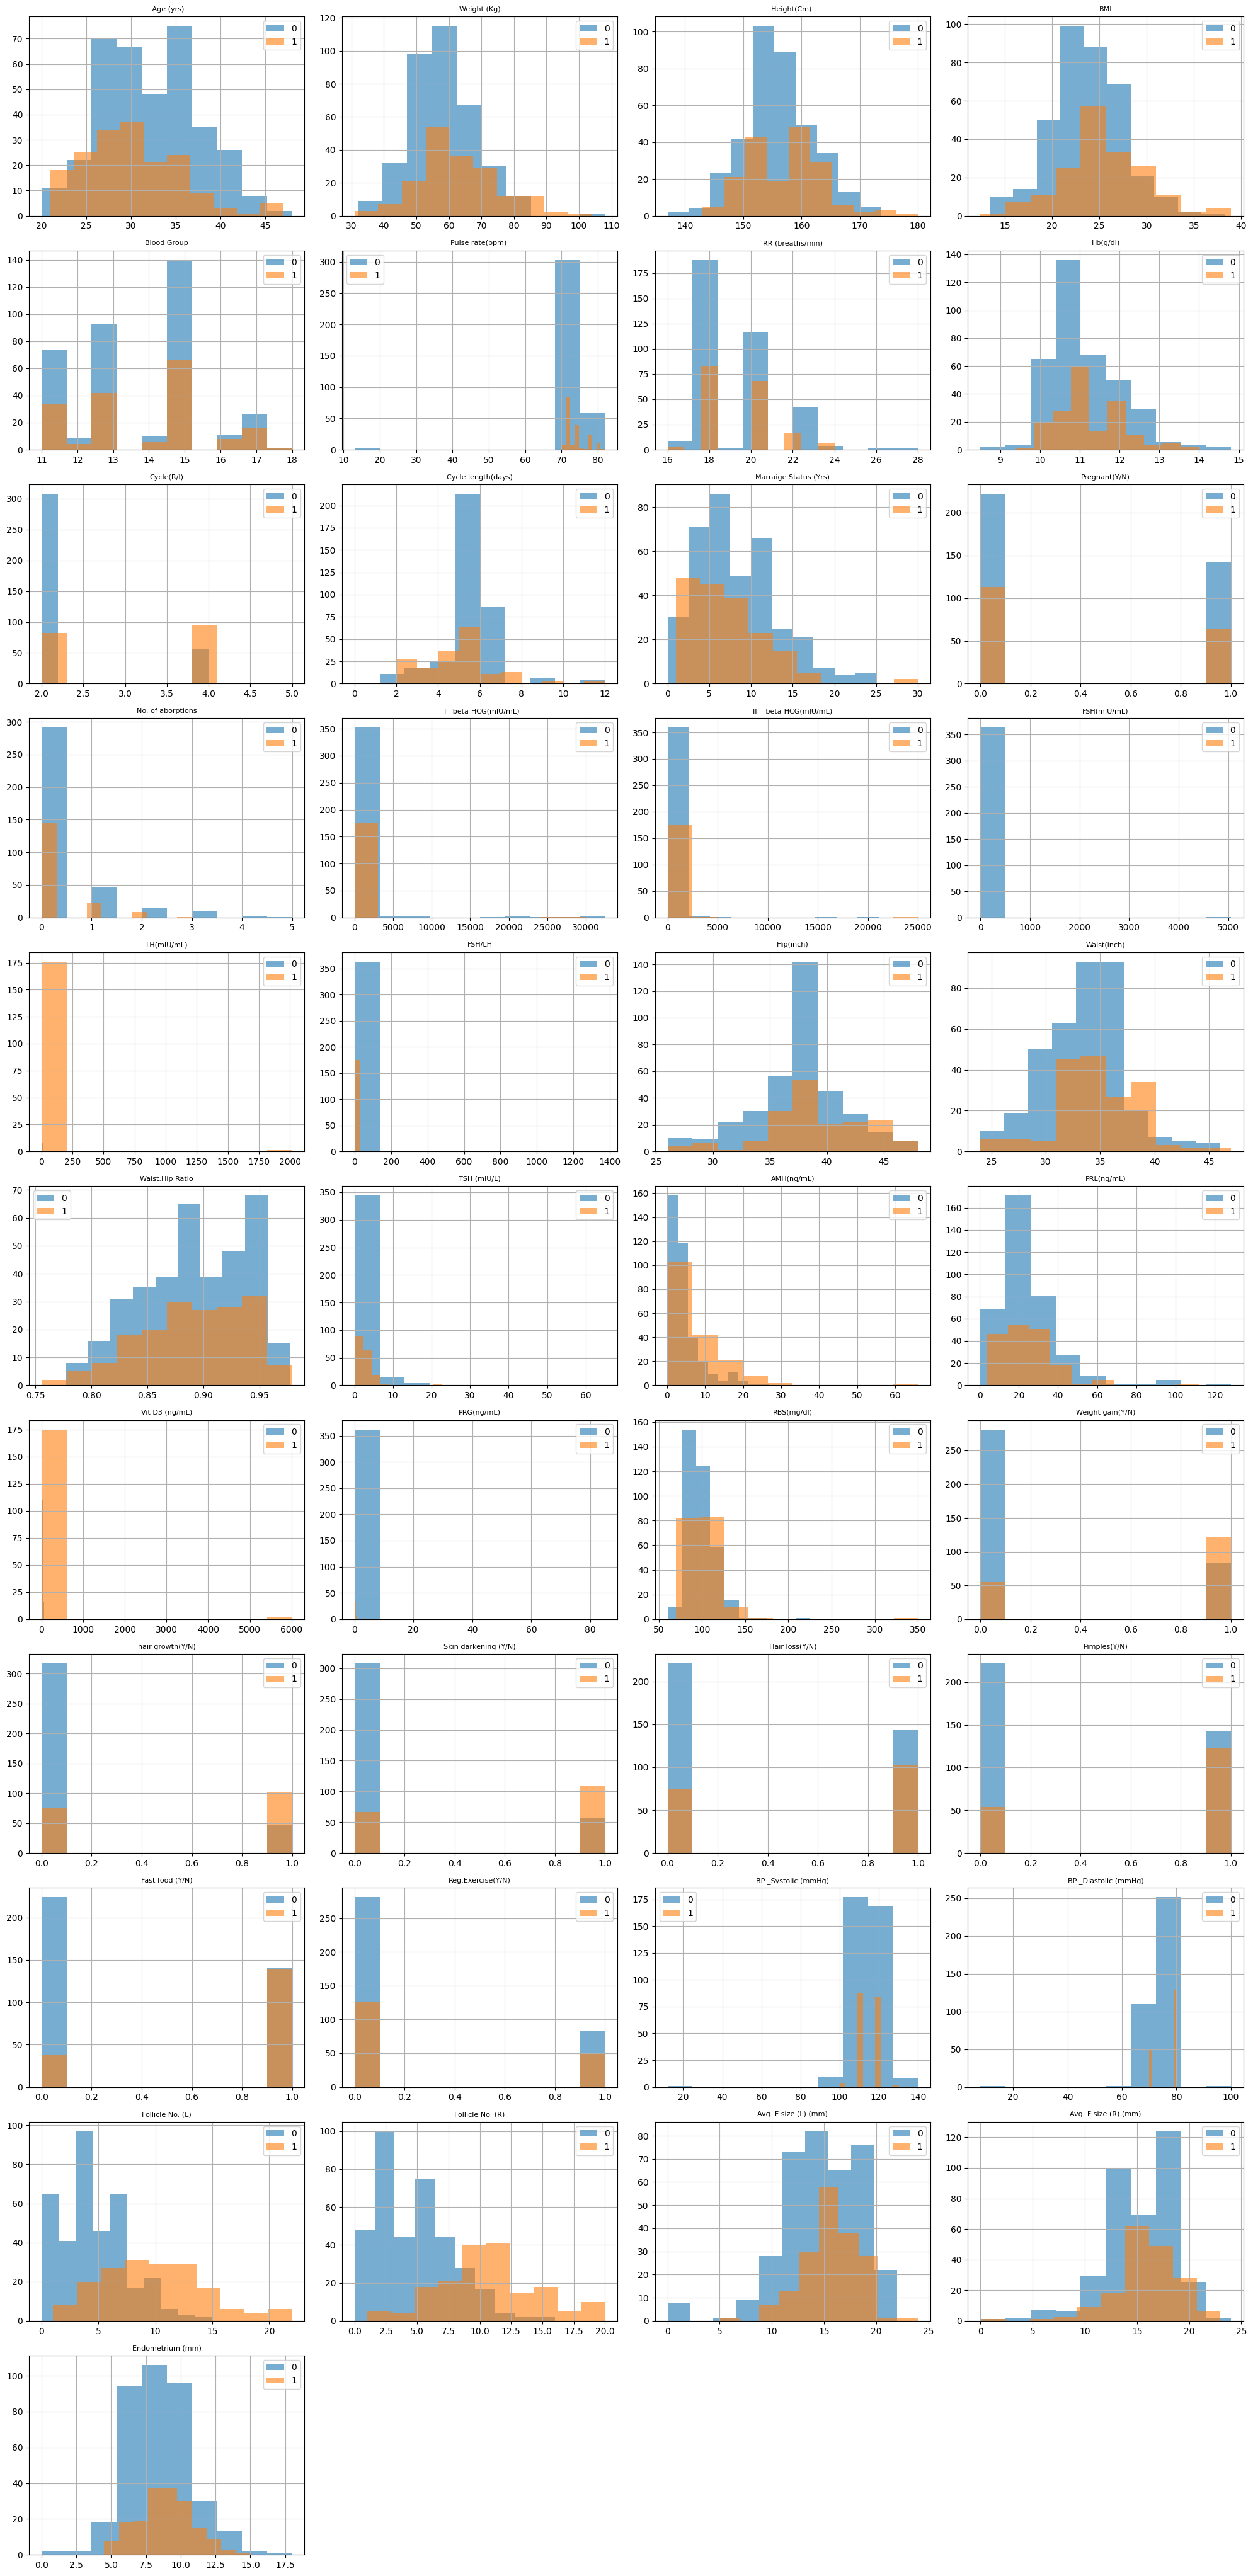

In [13]:
# Histogramas de todas as features numéricas, coloridos por classe
# Ajuda a visualizar se a distribuição de uma feature é diferente entre PCOS e não-PCOS
features_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
features_numericas = [f for f in features_numericas if f != 'PCOS (Y/N)']

fig, axes = plt.subplots(nrows=len(features_numericas) // 4 + 1, ncols=4, figsize=(20, len(features_numericas)))
axes = axes.flatten()

for i, col in enumerate(features_numericas):
    df.groupby('PCOS (Y/N)')[col].hist(alpha=0.6, ax=axes[i], legend=True)
    axes[i].set_title(col, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Discussão

### Balanceamento das classes

O dataset apresenta um desbalanceamento moderado: 67,3% das pacientes não possuem PCOS contra 32,7% com diagnóstico positivo. Embora não seja um desbalanceamento extremo, essa proporção de aproximadamente 2:1 deve ser considerada na etapa de modelagem — técnicas como `stratify` na separação treino/teste e métricas além da acurácia (como Recall e F1-score) serão importantes para evitar que o modelo favoreça a classe majoritária.

### Features com maior poder discriminativo

A análise das médias por classe revelou diferenças expressivas em diversas features:

- **Hormônio Luteinizante — LH** (+451%): a diferença mais marcante — pacientes com PCOS apresentam média de 14,40 mIU/mL contra 2,61 do grupo controle. O LH elevado é um dos critérios clínicos reconhecidos para diagnóstico de PCOS.
- **FSH** (-73%): comportamento inverso ao LH — média de 19,19 no grupo sem PCOS contra 5,17 no grupo com PCOS. A razão FSH/LH invertida é característica da síndrome.
- **Vitamina D3** (+215%): pacientes com PCOS apresentam média de 92,32 ng/mL contra 29,30. Essa diferença é surpreendentemente alta e merece investigação adicional na análise de correlação.
- **Contagem de folículos — L e R** (~+125%): ambas mais que dobram no grupo PCOS, consistente com o critério de ovários policísticos no ultrassom.
- **Sintomas clínicos**: crescimento de pelos (+342%), escurecimento da pele (+304%), ganho de peso (+200%) e espinhas (+78%) são todos significativamente mais frequentes no grupo PCOS, alinhados com os sinais clássicos de hiperandrogenismo.
- **AMH — Hormônio Anti-Mülleriano** (+73%): marcador conhecido de reserva ovariana elevada na síndrome.
- **Consumo de fast food** (+104%): interessante como fator comportamental associado.

### Valores ausentes

O dataset original apresentava poucos valores nulos: `Marraige Status (Yrs)` (1), `Fast food (Y/N)` (1) e a coluna `Unnamed: 44` (539 de 541 — artefato do Excel, removida). As colunas `II beta-HCG(mIU/mL)` e `AMH(ng/mL)` estavam armazenadas como texto (`object`) e precisaram de conversão para numérico, gerando 1 nulo cada após a conversão. Todos foram tratados via imputação pela mediana, estratégia adequada por ser robusta a outliers em dados médicos.

### Outliers

Nos histogramas, observa-se que features como `I beta-HCG`, `LH` e `Vit D3` possuem distribuições fortemente assimétricas à direita, com valores extremos que podem representar outliers. Esse comportamento é esperado em dados laboratoriais médicos. A presença desses valores deve ser considerada na escolha dos modelos — algoritmos baseados em árvores tendem a ser mais robustos a outliers que modelos lineares ou baseados em distância (KNN).